<a href="https://colab.research.google.com/github/realclovisworld/Neural_Networks/blob/main/Task_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TASK 9

**(QN)** Implement the standard VGG-16 & 19 CNN architecture model to classify multi category image dataset and check the accuracy

# STEPS

1. Import packages
2. Load the cifar10 dataset
3. Data preprocessing
4. Build VGG-16 Model
5. Train the Model
6. Evaluate the model
7. Compare VGG-16 accuracy to VGG-19


In [ ]:
#import libraries
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, Conv2D, MaxPooling2D
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical


In [ ]:
# Load the cifar10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

#Normalize pixel values using VGG's preprocess_input
x_train = preprocess_input(x_train)
x_test = preprocess_input(x_test)

#One-hot encode labels
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1752s 10us/step


In [ ]:
#Print the shape of the dataset

print('x_train shape:', x_train.shape)
print('y_train shape:', y_train.shape)

print(x_train.shape[0], 'train samples')
print(x_test.shape[0], 'test samples')

x_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 10)
50000 train samples
10000 test samples


In [ ]:
IMG_HEIGHT = 224
IMG_WIDTH = 224

def preprocess_image(image, label):
    image = tf.image.resize(image, (IMG_HEIGHT, IMG_WIDTH))
    return image, label

# Create TensorFlow datasets
train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train))
test_dataset = tf.data.Dataset.from_tensor_slices((x_test, y_test))

# Apply preprocessing to resize images
x_train_resized = train_dataset.map(preprocess_image).batch(32)
x_test_resized = test_dataset.map(preprocess_image).batch(32)


print('x_train_resized (as tf.data.Dataset):', x_train_resized)
print('x_test_resized (as tf.data.Dataset):', x_test_resized)

x_train_resized (as tf.data.Dataset): <_BatchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 10), dtype=tf.float64, name=None))>
x_test_resized (as tf.data.Dataset): <_BatchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 10), dtype=tf.float64, name=None))>


In [ ]:
# Build VGG-16 model

vgg16 = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

model_16 = Sequential()

model_16.add(vgg16)

model_16.add(Flatten())

model_16.add(Dense(512, activation='relu'))

model_16.add(Dropout(0.5))

model_16.add(Dense(10, activation='softmax'))

model_16.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,565,386 (105.15 MB)

 Trainable params: 27,565,386 (105.15 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Freeze the VGG-16 convolutional layers

vgg16.trainable = False

In [ ]:
# Compile VGG-16

model_16.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [ ]:
# Train VGG-16

history_16 = model_16.fit(
    x_train_resized,
    epochs=5,
    validation_data=x_test_resized
)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 312s 200ms/step - accuracy: 0.7502 - loss: 0.8291 - val_accuracy: 0.8409 - val_loss: 0.5399
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 301s 193ms/step - accuracy: 0.7945 - loss: 0.6940 - val_accuracy: 0.8437 - val_loss: 0.5313
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 301s 193ms/step - accuracy: 0.8123 - loss: 0.6381 - val_accuracy: 0.8589 - val_loss: 0.5337
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 300s 192ms/step - accuracy: 0.8236 - loss: 0.6221 - val_accuracy: 0.8546 - val_loss: 0.5553
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 301s 193ms/step - accuracy: 0.8331 - loss: 0.5939 - val_accuracy: 0.8521 - val_loss: 0.5730


In [ ]:
  # Check VGG-16 accuracy

loss_16, accuracy_16 = model_16.evaluate(x_test_resized)

print('VGG-16 Test Accuracy:', accuracy_16)

313/313 ━━━━━━━━━━━━━━━━━━━━ 64s 205ms/step - accuracy: 0.8557 - loss: 0.5928
VGG-16 Test Accuracy: 0.8557000160217285


# VGG-19 MODEL

In [ ]:
from tensorflow.keras.applications import VGG19

# Build VGG-19 model

vgg19 = VGG19(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

vgg19.trainable = False # Freeze VGG-19 convolutional layers here

model_19 = Sequential()

model_19.add(vgg19)

model_19.add(Flatten())

model_19.add(Dense(512, activation='relu'))

model_19.add(Dropout(0.5))

model_19.add(Dense(10, activation='softmax'))

model_19.summary()

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,875,082 (125.41 MB)

 Trainable params: 12,850,698 (49.02 MB)

 Non-trainable params: 20,024,384 (76.39 MB)

In [ ]:
# Compile VGG-19

model_19.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [ ]:
# Train VGG-19

history_19 = model_19.fit(
    x_train_resized,
    epochs=10,
    validation_data=x_test_resized
)

Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 491s 312ms/step - accuracy: 0.7033 - loss: 1.2741 - val_accuracy: 0.8352 - val_loss: 0.5516
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 497s 310ms/step - accuracy: 0.7874 - loss: 0.7352 - val_accuracy: 0.8546 - val_loss: 0.4838
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 487s 312ms/step - accuracy: 0.8100 - loss: 0.6642 - val_accuracy: 0.8491 - val_loss: 0.5118


In [ ]:
# Check VGG-19 accuracy

loss_19, accuracy_19 = model_19.evaluate(x_test_resized)

print('VGG-19 Test Accuracy:', accuracy_19)

313/313 ━━━━━━━━━━━━━━━━━━━━ 80s 257ms/step - accuracy: 0.8491 - loss: 0.5118
VGG-19 Test Accuracy: 0.8490999937057495


In [ ]:
# Compare VGG-16 and VGG-19 accuracy

print('VGG-16 Test Accuracy:', accuracy_16)
print('VGG-19 Test Accuracy:', accuracy_19)

VGG-16 Test Accuracy: 0.8557000160217285
VGG-19 Test Accuracy: 0.8490999937057495


In [ ]:
import numpy as np


# Get a batch of images and labels from the test dataset
for test_images, test_labels in x_test_resized.take(1):
    break

# Make predictions with model_19
predictions = model_19.predict(test_images)

# Display the predicted probabilities for the first few images
print('Predictions for the first 5 images in the batch:')
for i in range(5):
    print(f'Image {i+1}: Predicted probabilities: {predictions[i]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predictions for the first 5 images in the batch:
Image 1: Predicted probabilities: [9.4094850e-07 3.7156010e-08 1.1151632e-02 9.2634648e-01 2.9036682e-04
 1.7718477e-02 4.3562248e-02 9.2996977e-04 6.9950419e-09 1.8954478e-14]
Image 2: Predicted probabilities: [1.0969893e-11 2.0632912e-11 2.8401065e-24 2.5657709e-26 3.7203948e-33
 2.9198760e-37 3.1296113e-27 7.3018175e-33 1.0000000e+00 3.7588049e-14]
Image 3: Predicted probabilities: [2.21171198e-04 8.87326598e-01 2.05802562e-12 2.95207914e-10
 5.28535049e-15 3.88322230e-12 2.33487913e-08 6.71213895e-16
 1.09885976e-01 2.56628287e-03]
Image 4: Predicted probabilities: [9.77204204e-01 4.35146457e-03 4.37466614e-03 1.03216916e-02
 6.12578995e-04 1.07957014e-04 3.39894817e-04 2.53697217e-04
 2.33108108e-03 1.02738108e-04]
Image 5: Predicted probabilities: [6.3184915e-19 1.5237393e-33 1.3750473e-01 1.5819672e-04 1.1184035e-03
 3.7378740e-08 8.6121863e-01 4.3907606e-09 9.3410629e-23 7.0018295e-28]


In [ ]:
print('\nActual labels for the first 5 images in the batch:')
for i in range(5):
    print(f'Image {i+1}: Actual label (one-hot encoded): {test_labels[i]}')
    print(f'Image {i+1}: Actual class index: {np.argmax(test_labels[i])}')
    print(f'Image {i+1}: Predicted class index: {np.argmax(predictions[i])}')


Actual labels for the first 5 images in the batch:
Image 1: Actual label (one-hot encoded): [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
Image 1: Actual class index: 3
Image 1: Predicted class index: 3
Image 2: Actual label (one-hot encoded): [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
Image 2: Actual class index: 8
Image 2: Predicted class index: 8
Image 3: Actual label (one-hot encoded): [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
Image 3: Actual class index: 8
Image 3: Predicted class index: 1
Image 4: Actual label (one-hot encoded): [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Image 4: Actual class index: 0
Image 4: Predicted class index: 0
Image 5: Actual label (one-hot encoded): [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
Image 5: Actual class index: 6
Image 5: Predicted class index: 6


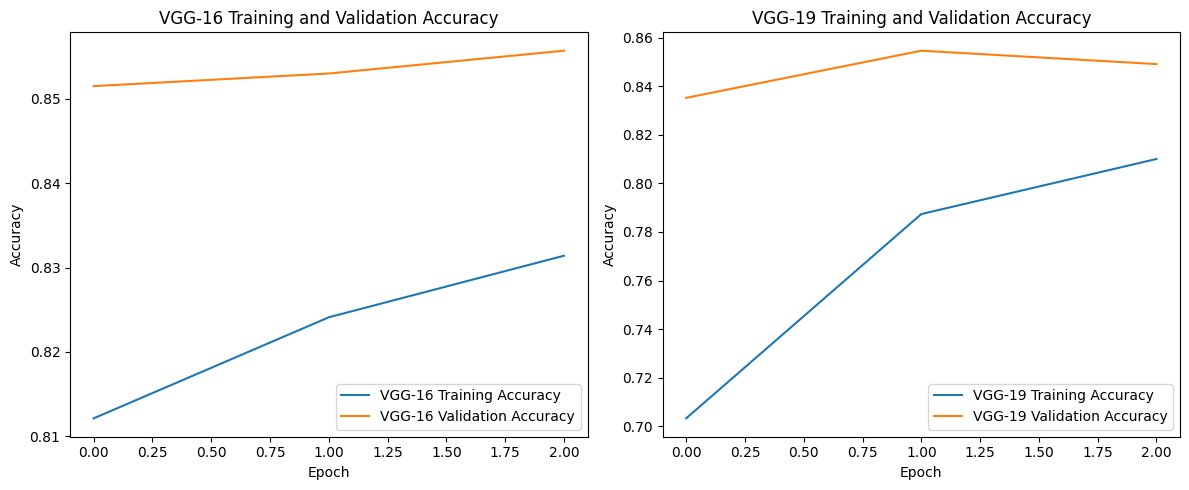

In [ ]:
plt.figure(figsize=(12, 5))

# Plot VGG-16 Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_16.history['accuracy'], label='VGG-16 Training Accuracy')
plt.plot(history_16.history['val_accuracy'], label='VGG-16 Validation Accuracy')
plt.title('VGG-16 Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot VGG-19 Accuracy
plt.subplot(1, 2, 2)
plt.plot(history_19.history['accuracy'], label='VGG-19 Training Accuracy')
plt.plot(history_19.history['val_accuracy'], label='VGG-19 Validation Accuracy')
plt.title('VGG-19 Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()